In [1]:
from glob import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
!ls -al binaural_eval/

total 0
drwxrwxr-x 2 imgriff mcdermott 4096 Jul 17 18:39 .
drwxr-xr-x 2 imgriff mcdermott 4096 Aug 10 22:21 ..
drwxrwxr-x 2 imgriff mcdermott 4096 Jul 17 20:48 word_task_voice_loc_cue


In [13]:
# !ls binaural_eval/word_task_voice_loc_cue

In [14]:
# test_files = glob('binaural_eval/word_task_voice_and_loc_cue_8_01/*.pkl')
test_files = glob('binaural_eval/word_task_voice_loc_cue/*.pkl')


In [15]:
result_df = pd.DataFrame()
condition = []
target_loc = []
distractor_loc = []
accuracy = []
acc_error = []
confusions = []
con_error = []
for f in test_files:
    file_dict = pd.read_pickle(f)
    for con in file_dict.keys():
        condition.append(con)
        targ_loc = file_dict[con]['target_loc']
        if targ_loc[0] > 90:
            azim = 360 - targ_loc[0]
        else:
            azim = 0 - targ_loc[0]
        target_loc.append((azim, 0))
        dist_loc = file_dict[con]['distract_loc']
        if dist_loc[0] > 90:
            azim = 360 - dist_loc[0]
        else:
            azim = 0 - dist_loc[0]
        distractor_loc.append((azim, 0))
        accuracy.append(file_dict[con]['results'][0])
        acc_error.append(file_dict[con]['results'][1])
        confusions.append(file_dict[con]['confusions'][0])
        con_error.append(file_dict[con]['confusions'][1])

result_df['condition'] = condition
result_df['target_loc'] = target_loc
result_df['distractor_loc'] = distractor_loc
result_df['accuracy'] = accuracy
result_df['acc_error'] = acc_error
result_df['confusions'] = confusions
result_df['con_error'] = con_error

In [16]:
result_df

,condition,target_loc,distractor_loc,accuracy,acc_error,confusions,con_error
0,m_m,"(0, 0)","(0, 0)",0.084918,0.009930,0.238276,0.015177
1,m_f,"(0, 0)","(0, 0)",0.097592,0.010572,0.185044,0.013834
2,f_m,"(0, 0)","(0, 0)",0.097592,0.010572,0.200253,0.014256
3,f_f,"(0, 0)","(0, 0)",0.082383,0.009795,0.271229,0.015838
4,m_m,"(0, 0)","(-10, 0)",0.110266,0.011158,0.179975,0.013685
...,...,...,...,...,...,...,...
1439,f_f,"(-90, 0)","(-80, 0)",0.068441,0.008995,0.278834,0.015975
1440,m_m,"(-90, 0)","(-90, 0)",0.084918,0.009930,0.247148,0.015366
1441,m_f,"(-90, 0)","(-90, 0)",0.098859,0.010633,0.178707,0.013648
1442,f_m,"(-90, 0)","(-90, 0)",0.110266,0.011158,0.205323,0.014390


<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

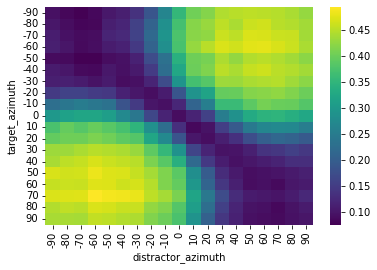

In [42]:
mean_acc = result_df.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(mean_acc.unstack(), cmap='viridis')

<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

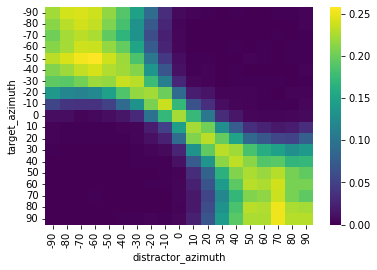

In [44]:
mean_con = result_df.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(mean_con.unstack(), cmap='viridis')

In [46]:
same_sex = result_df[(result_df['condition'] == 'm_m') | (result_df['condition'] == 'f_f')]
print(same_sex['accuracy'].max())

0.4955640050697085


<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

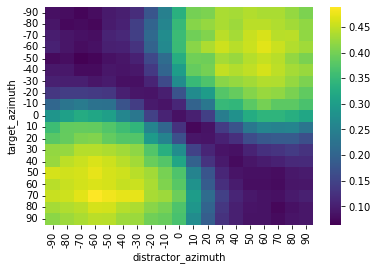

In [47]:
mean_acc = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(mean_acc.unstack(), cmap='viridis')

<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

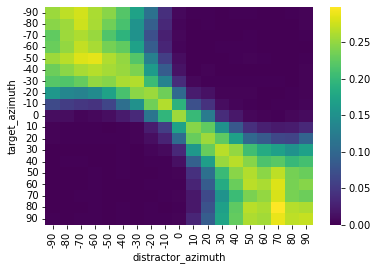

In [48]:
mean_con = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(mean_con.unstack(), cmap='viridis')

In [49]:
diff_sex = result_df[(result_df['condition'] == 'm_f') | (result_df['condition'] == 'f_m')]
print(diff_sex['accuracy'].max())

0.5082382762991128


<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

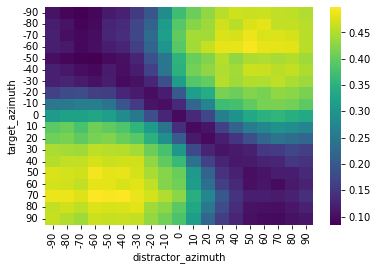

In [50]:
mean_acc = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(mean_acc.unstack(), cmap='viridis')

<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

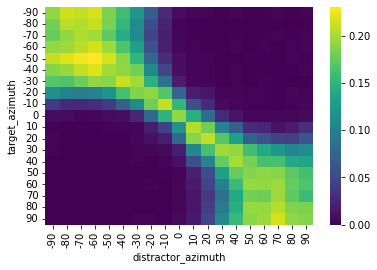

In [51]:
mean_con = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(mean_con.unstack(), cmap='viridis')

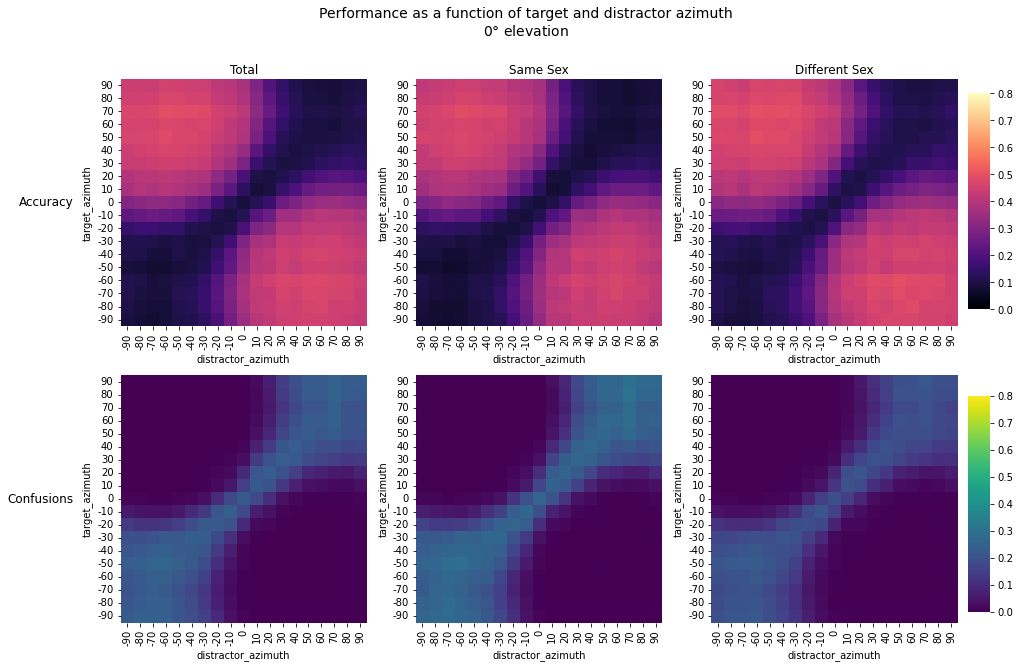

In [64]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# cbar_ax_1 = fig.add_axes([.91, .53, .03, .4])
# cbar_ax_2 = fig.add_axes([.91, .1, .03, .4])

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = result_df.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = result_df.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.8, cmap='viridis', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex_acc = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(same_sex_con.unstack(), vmin=0, vmax=0.8, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex_acc = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(diff_sex_con.unstack(), vmin=0, vmax=0.8, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 2])

# np.vectorize(lambda ax: ax.invert_yaxis())(axs.flatten())
for ax in axs.flatten():
    ax.invert_yaxis()

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points')
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center')
# fig.tight_layout(rect=[0,0,.9,1])

plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation', fontsize=14, y=0.98);



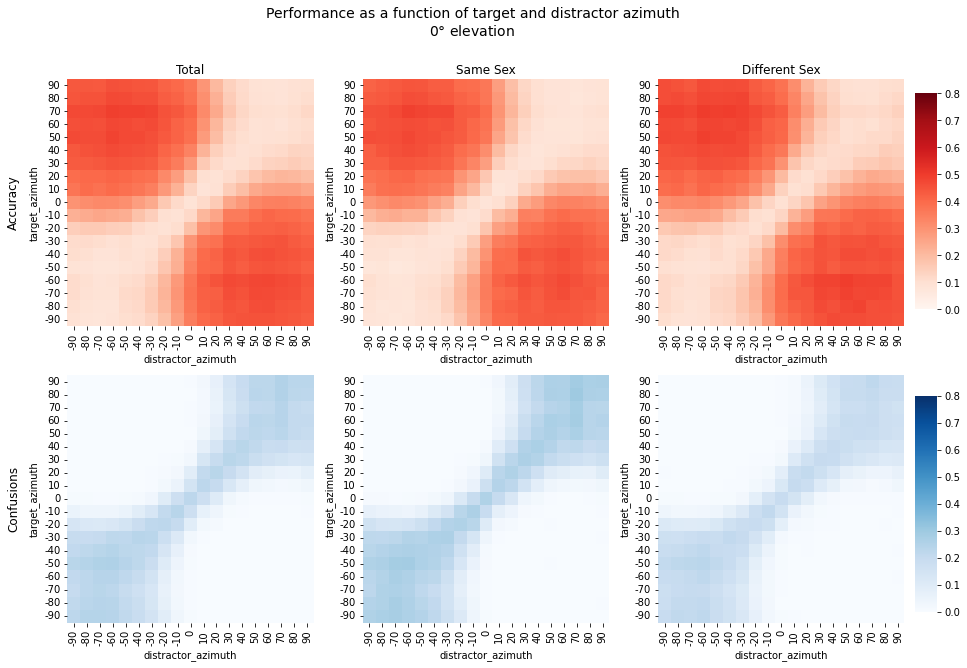

In [66]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = result_df.groupby(["target_azimuth", "distractor_azimuth"]).mean()['accuracy']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=.8, cmap='Reds', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = result_df.groupby(["target_azimuth", "distractor_azimuth"]).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.8, cmap='Blues', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex_acc = same_sex.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean()
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax= .8, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean()
sns.heatmap(same_sex_con.unstack(), vmin=0, vmax=0.8, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex_acc = diff_sex.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean()
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=.8, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean()
sns.heatmap(diff_sex_con.unstack(), vmin=0, vmax=0.8, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 2])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

for ax in axs.flatten():
    ax.invert_yaxis()
    
# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation', fontsize=14, y=0.98);

# np.vectorize(lambda ax: ax.invert_yaxis())(axs);

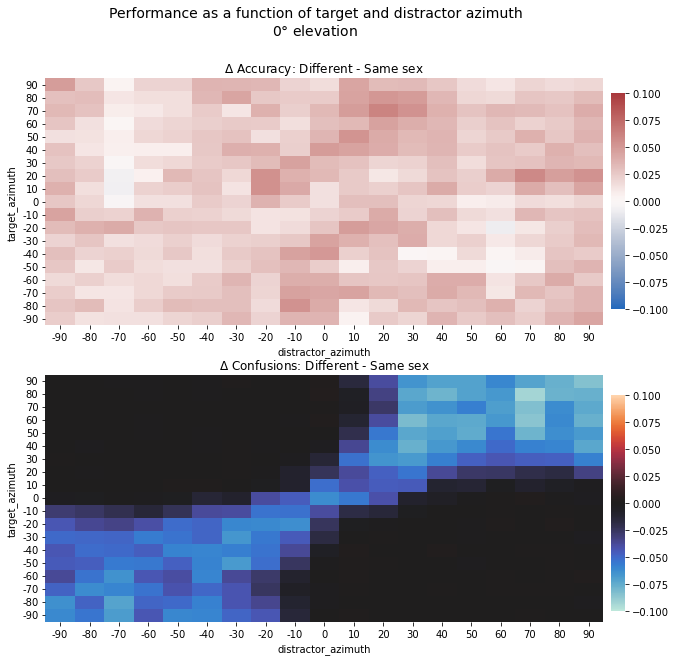

In [86]:
# plot all plots so far onto one figure
# cols = ['Total', 'Same Sex', 'Different Sex']
# rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=False, sharey=True)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

diff = diff_sex.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean() - same_sex.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean()
sns.heatmap(diff.unstack(), vmin=-0.1, vmax=0.1, cmap='vlag', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0])
diff = diff_sex.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean() - same_sex.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean()
sns.heatmap(diff.unstack(), vmin=-0.1, vmax=0.1, cmap='icefire', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1])

# for ax, col in zip(axs[0], cols):
axs[0].set_title("$\Delta$ Accuracy: Different - Same sex ", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("$\Delta$ Confusions: Different - Same sex") # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation', fontsize=14, y=0.98);

np.vectorize(lambda ax: ax.invert_yaxis())(axs);